# 10. Quantization

**Tier:** Training
**Estimated time:** 50 minutes
**Prerequisites:** 00–08
**Source material:** Stanford LLM curriculum, Lecture 4 (quantization, QLoRA)

> **Compute note:** Everything here runs on CPU. We quantize real GPT-2 weights to measure the effect; no GPU needed.

## What You'll Learn
- What **quantization** is: storing weights in 8 or 4 bits instead of 32, and why that barely hurts quality
- **Symmetric (absmax) quantization** implemented from scratch — quantize, dequantize, measure the error
- The memory ↔ accuracy tradeoff across bit-widths, and why **per-channel** quantization beats per-tensor

## Why This Matters
A 7B model in fp32 is ~28GB — too big for most GPUs. Quantize to 4-bit and it's ~3.5GB, fitting on a laptop. Quantization is what put capable LLMs on consumer hardware, and it's the "Q" in QLoRA (notebook 08). The surprise is how *little* accuracy you lose.

In [ ]:
import os

# Load .env if python-dotenv is installed; harmless if it isn't.
# Not required for this notebook (runs fully offline with PyTorch/transformers).
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

## The core idea: round to a coarser grid

A 32-bit float can represent billions of values. But a neural network's weights cluster in a small range (say −0.4 to +0.4), and the model is robust to small perturbations. So why spend 32 bits per weight?

**Quantization** maps the continuous weight range onto a small set of integers — 256 levels for 8-bit, 16 levels for 4-bit. It's the same idea as rounding every price in a shop to the nearest dollar: you lose a few cents of precision but the receipt is far simpler to store.

**Symmetric (absmax) quantization** in three numbers:
```
scale = max(|W|) / qmax          # qmax = 127 for int8
W_quant = round(W / scale)       # now small integers in [-127, 127]
W_dequant = W_quant * scale      # reconstruct an approximation
```
We store `W_quant` (1 byte each) plus one `scale` per tensor. Let's build it.

In [1]:
import torch
import numpy as np

def quantize_symmetric(W, bits=8):
    qmax = 2 ** (bits - 1) - 1                 # 127 for int8, 7 for int4
    scale = W.abs().max() / qmax               # one scale for the whole tensor
    W_q = torch.round(W / scale).clamp(-qmax, qmax)
    return W_q, scale

def dequantize(W_q, scale):
    return W_q * scale

# Try it on a small random weight matrix.
torch.manual_seed(0)
W = torch.randn(4, 4) * 0.3
W_q, scale = quantize_symmetric(W, bits=8)
W_hat = dequantize(W_q, scale)

print("original W[0]      :", np.round(W[0].numpy(), 4))
print("quantized ints W_q :", W_q[0].int().numpy())
print("reconstructed W_hat:", np.round(W_hat[0].numpy(), 4))
print(f"\nmax reconstruction error: {(W - W_hat).abs().max():.5f}")

original W[0]      : [-0.3378 -0.3457 -0.0752 -0.1302]
quantized ints W_q : [-68 -69 -15 -26]
reconstructed W_hat: [-0.3398 -0.3448 -0.0749 -0.1299]

max reconstruction error: 0.00249


*We stored the weights as small integers plus a single scale factor, then reconstructed values very close to the originals. The error is on the order of one quantization step — usually negligible for a robust network.*

## Bit-width vs error vs memory

Fewer bits = less memory but a coarser grid = more error. Let's sweep bit-widths on a real GPT-2 weight matrix and watch the tradeoff. We measure error as the relative reconstruction error `‖W − Ŵ‖ / ‖W‖`.

In [2]:
try:
    from transformers import GPT2Model
    gpt2 = GPT2Model.from_pretrained("gpt2")
    # A real weight matrix from the first attention block.
    W = gpt2.h[0].mlp.c_fc.weight.detach().float()
    print("Using a real GPT-2 weight matrix:", tuple(W.shape))
except Exception as e:
    W = torch.randn(768, 3072) * 0.05
    print("Offline — using a synthetic weight matrix:", tuple(W.shape))
    print(repr(e)[:150])

def rel_error(W, bits):
    W_q, scale = quantize_symmetric(W, bits)
    return float((W - dequantize(W_q, scale)).norm() / W.norm())

bit_widths = [16, 8, 6, 4, 3, 2]
errors = [rel_error(W, b) for b in bit_widths]
mem = [W.numel() * b / 8 / 1e6 for b in bit_widths]   # megabytes
for b, e, m in zip(bit_widths, errors, mem):
    print(f"  {b:2d}-bit:  rel error {e:.4f}   memory {m:6.2f} MB")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Using a real GPT-2 weight matrix: (768, 3072)
  16-bit:  rel error 0.0003   memory   4.72 MB
   8-bit:  rel error 0.0739   memory   2.36 MB
   6-bit:  rel error 0.2987   memory   1.77 MB
   4-bit:  rel error 0.9156   memory   1.18 MB
   3-bit:  rel error 0.9973   memory   0.88 MB
   2-bit:  rel error 0.9992   memory   0.59 MB


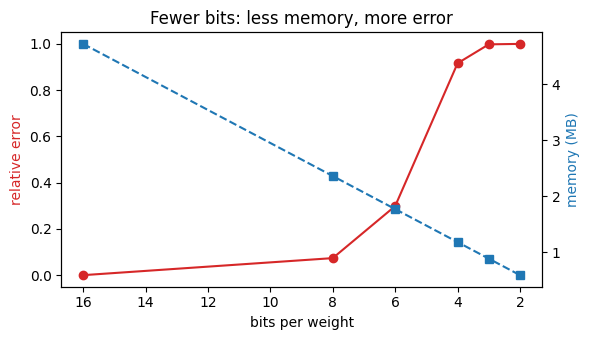

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(6, 3.5))
ax1.plot(bit_widths, errors, "o-", color="tab:red", label="reconstruction error")
ax1.set_xlabel("bits per weight"); ax1.set_ylabel("relative error", color="tab:red")
ax1.invert_xaxis()
ax2 = ax1.twinx()
ax2.plot(bit_widths, mem, "s--", color="tab:blue", label="memory (MB)")
ax2.set_ylabel("memory (MB)", color="tab:blue")
plt.title("Fewer bits: less memory, more error")
plt.tight_layout(); plt.show()

*8-bit is nearly free (tiny error, 4× smaller than fp32). The error stays small down to ~4-bit, then climbs sharply. That 'cliff' is why 4-bit is the popular sweet spot — and why naive 2-bit quantization needs much cleverer methods.*

## Why per-channel beats per-tensor

A single scale for the whole matrix is hostage to its largest value: one big outlier weight stretches the scale and wastes precision on every other weight. **Per-channel** quantization uses a separate scale per row (output channel), so outliers in one channel don't degrade the others. This simple change is standard in production quantization.

In [4]:
def quantize_per_channel(W, bits=8):
    qmax = 2 ** (bits - 1) - 1
    scale = W.abs().max(dim=1, keepdim=True).values / qmax   # one scale PER ROW
    W_q = torch.round(W / scale).clamp(-qmax, qmax)
    return W_q, scale

# Inject an outlier to dramatize the difference.
W_out = W.clone(); W_out[0, 0] = W.abs().max() * 8

per_tensor = rel_error(W_out, 4)
Wq, s = quantize_per_channel(W_out, 4)
per_channel = float((W_out - Wq * s).norm() / W_out.norm())
print(f"4-bit with an outlier:")
print(f"  per-tensor  rel error: {per_tensor:.4f}")
print(f"  per-channel rel error: {per_channel:.4f}   <- much better")

4-bit with an outlier:
  per-tensor  rel error: 0.9853
  per-channel rel error: 0.2130   <- much better


## Connecting to QLoRA

Recall LoRA from notebook 08. **QLoRA** quantizes the frozen base model to 4-bit (what you just did), then trains full-precision LoRA adapters on top. The base barely uses memory; the adapters are tiny and stay precise. That combination is how a 65B model gets fine-tuned on a single GPU — and you've now implemented both halves from scratch.

## Exercises

In [5]:
# Exercise 1 (Warm-up): Find the cliff on YOUR matrix
# Task: Re-run the bit-width sweep on a different GPT-2 weight (e.g. gpt2.h[0].attn.c_attn.weight)
#       and identify the bit-width where relative error first exceeds 1%.
# Hint: Just point W at a different tensor and reuse rel_error.

# YOUR CODE HERE

In [6]:
# Exercise 2 (Apply): Affine (asymmetric) quantization
# Task: Implement quantize_affine(W, bits) using a zero-point so the grid spans [min, max]
#       instead of being symmetric around 0. Compare its error to symmetric on a tensor whose
#       values are all positive (e.g. W.abs()).
# Hint: scale = (max-min)/(2^bits-1); zero_point = round(-min/scale); q = round(W/scale)+zp.

# YOUR CODE HERE

In [7]:
# Exercise 3 (Extend): Does quantization break generation?
# Task: Quantize ALL of GPT-2's weights to 8-bit in place (dequantized back to float), then
#       generate text and compare to the original. Is the output still coherent?
# Hint: Loop over model.parameters(); for 2D weights, replace data with dequantize(quantize(...)).
#       This simulates int8 inference. (Requires the transformers GPT-2 from earlier.)

# YOUR CODE HERE

<details>
<summary>Show solutions</summary>

```python
# Exercise 2
def quantize_affine(W, bits=8):
    qmax = 2 ** bits - 1
    w_min, w_max = W.min(), W.max()
    scale = (w_max - w_min) / qmax
    zero_point = torch.round(-w_min / scale)
    W_q = (torch.round(W / scale) + zero_point).clamp(0, qmax)
    W_hat = (W_q - zero_point) * scale
    return W_q, scale, zero_point, W_hat
Wp = W.abs()
_, _, _, Wh = quantize_affine(Wp, 4)
print("affine rel error on positive data:", float((Wp - Wh).norm() / Wp.norm()))
# Affine uses the full grid for one-sided data; symmetric wastes half its levels there.

# Exercise 3
import copy
m = copy.deepcopy(gpt2)
with torch.no_grad():
    for p in m.parameters():
        if p.dim() == 2:
            q, s = quantize_per_channel(p.data, 8)
            p.data.copy_(q * s)
# Then run generation with this model — 8-bit output is essentially indistinguishable.
```
</details>

## Key Takeaways
- **Quantization** stores weights on a coarse integer grid (8 or 4 bits) plus a scale, slashing memory ~4–8× with little accuracy loss.
- **Symmetric absmax** quantization is three lines: divide by a scale, round, clamp; dequantize by multiplying back.
- There's an error **cliff** below ~4 bits, which is why 4-bit is the practical floor for naive methods.
- **Per-channel** scales tame outliers that would otherwise wreck per-tensor quantization — and 4-bit quantization + LoRA = **QLoRA**.

## What's Next
Notebook **11 — Speculative Decoding** closes Tier 2: a clever trick to make a *quantized, aligned* model generate text 2–3× faster by having a small model guess ahead and the big model verify.